In [1]:
!pip install dicom2nifti nibabel nilearn


   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 3.3/3.3 MB 27.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ------------------ --------------------- 4.7/10.5 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 36.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 68.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.9 MB ? eta -:--:--
   ---------- ----------------------------- 7.3/28.9 MB 37.6 MB/s eta 0:00:01
   ------------------------ --------------- 17.8/28.9 MB 44.9 MB/s eta 0:00:01
   ------------------------------ --------- 22.0/28.9 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 28.9/28.9 MB 36.6 MB/s eta 0:00:00


**DICOM Metadata:**
Patient ID: 002_S_2073
Patient Sex: F
Modality: MR
Scan Date: 20100907
Institution: OHSU MRI3
Repetition Time (TR): 2250
Echo Time (TE): 30.001


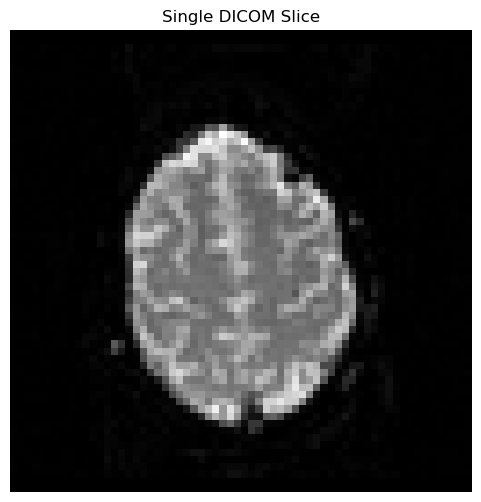

In [29]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# Load a single DICOM file
dicom_path = r"./ADNI/fMRI/ADNI/002_S_2073/Resting_State_fMRI/2010-09-07_07_11_14.0/I192250/ADNI_002_S_2073_MR_Resting_State_fMRI_br_raw_20100908060012274_4322_S91779_I192250.dcm"  # Change this to a real DICOM file path
dicom_data = pydicom.dcmread(dicom_path)

# Extract metadata
metadata_info = {
    "Patient ID": dicom_data.PatientID,
    "Patient Sex": dicom_data.PatientSex,
    "Modality": dicom_data.Modality,
    "Scan Date": dicom_data.StudyDate,
    "Institution": dicom_data.get("InstitutionName", "N/A"),
    "Repetition Time (TR)": dicom_data.get("RepetitionTime", "N/A"),
    "Echo Time (TE)": dicom_data.get("EchoTime", "N/A"),
}

# Print metadata
print("**DICOM Metadata:**")
for key, value in metadata_info.items():
    print(f"{key}: {value}")

# Extract and display the image
image_data = dicom_data.pixel_array
plt.figure(figsize=(6,6))
plt.imshow(image_data, cmap="gray")
plt.title("Single DICOM Slice")
plt.axis("off")
plt.show()


In [12]:
import dicom2nifti
import nibabel as nib
from nilearn import plotting

# Define DICOM folder path
dicom_folder = r"./ADNI/fMRI/ADNI/002_S_2073/Resting_State_fMRI/2010-09-07_07_11_14.0/I192250"  # Folder containing multiple DICOM files
nifti_output = r"./ADNI/fMRI/ADNI/002_S_2073/Resting_State_fMRI/2010-09-07_07_11_14.0/I192250/I192250_resting_state_fmri.nii.gz"

# Convert DICOM folder to NIfTI
dicom2nifti.convert_directory(dicom_folder, os.path.dirname(nifti_output))
print(f"NIfTI file saved at {nifti_output}")



NIfTI file saved at ./ADNI/fMRI/ADNI/002_S_2073/Resting_State_fMRI/2010-09-07_07_11_14.0/I192250/I192250_resting_state_fmri.nii.gz


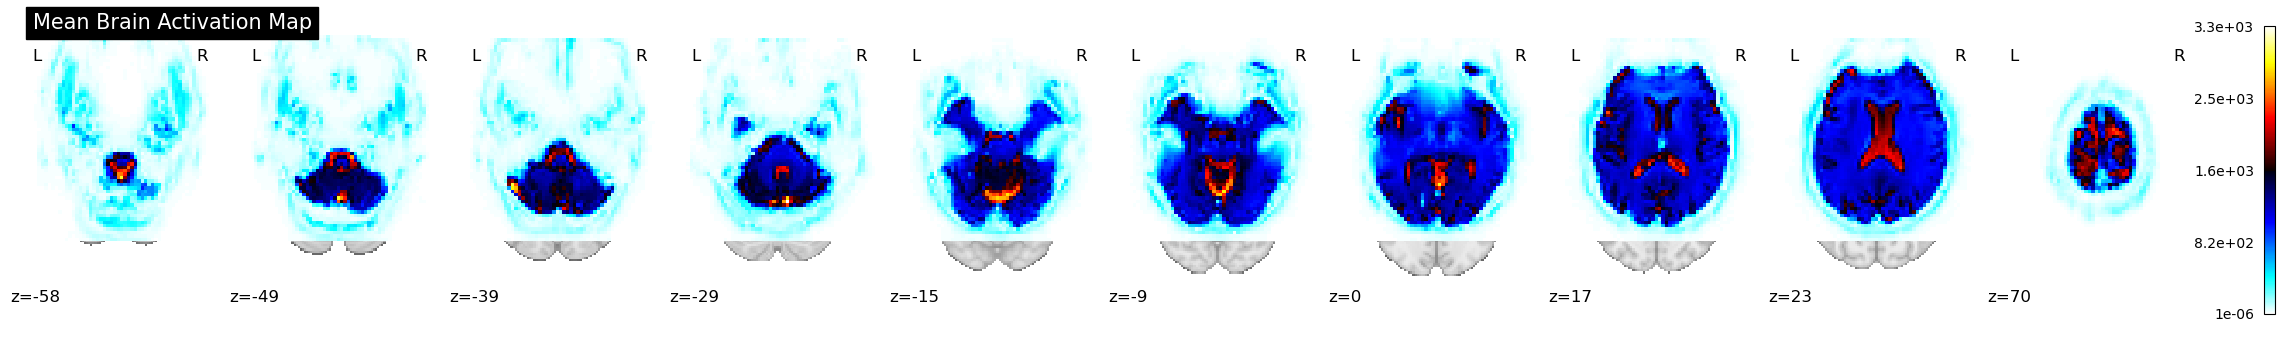

In [22]:
import nibabel as nib
import numpy as np
from nilearn import plotting

# Load the 4D fMRI NIfTI file
nifti_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I552093\501_extended_resting_state_fmri.nii.gz"
fmri_img = nib.load(nifti_path)

# Convert 4D to 3D: Take the mean across time
fmri_data = fmri_img.get_fdata()
mean_fmri_3d = np.mean(fmri_data, axis=-1)  # Averaging across time

# Save the 3D mean image as a new NIfTI file
mean_nifti = nib.Nifti1Image(mean_fmri_3d, affine=fmri_img.affine)
mean_nifti_path = "mean_fmri_3d.nii.gz"
nib.save(mean_nifti, mean_nifti_path)

# Now, plot the 3D NIfTI
plotting.plot_stat_map(mean_nifti_path, display_mode='z', cut_coords=10, title="Mean Brain Activation Map")
plotting.show()


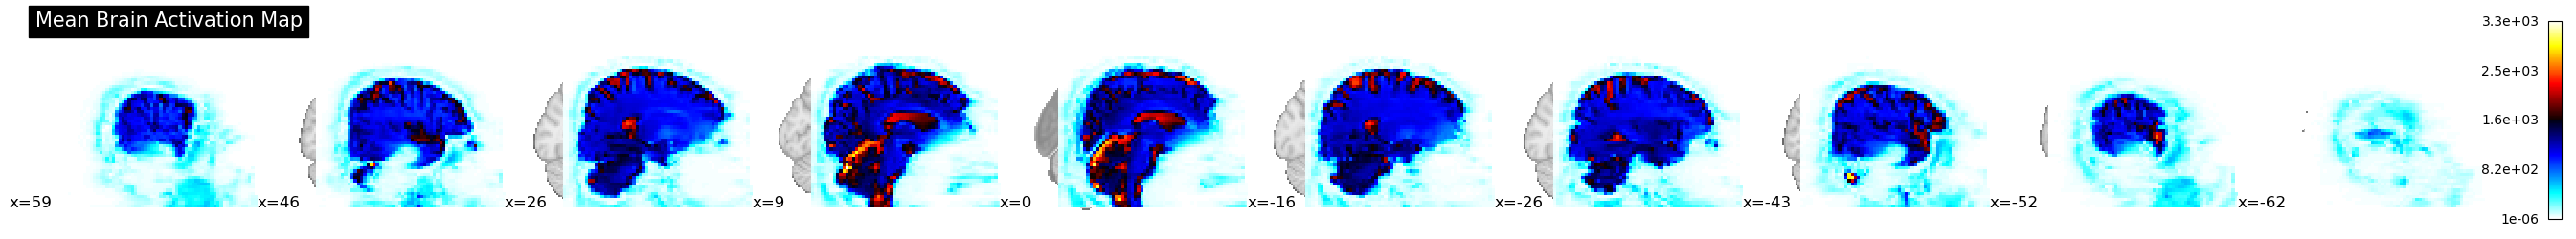

In [23]:
# Now, plot the 3D NIfTI
plotting.plot_stat_map(mean_nifti_path, display_mode='x', cut_coords=10, title="Mean Brain Activation Map")
plotting.show()

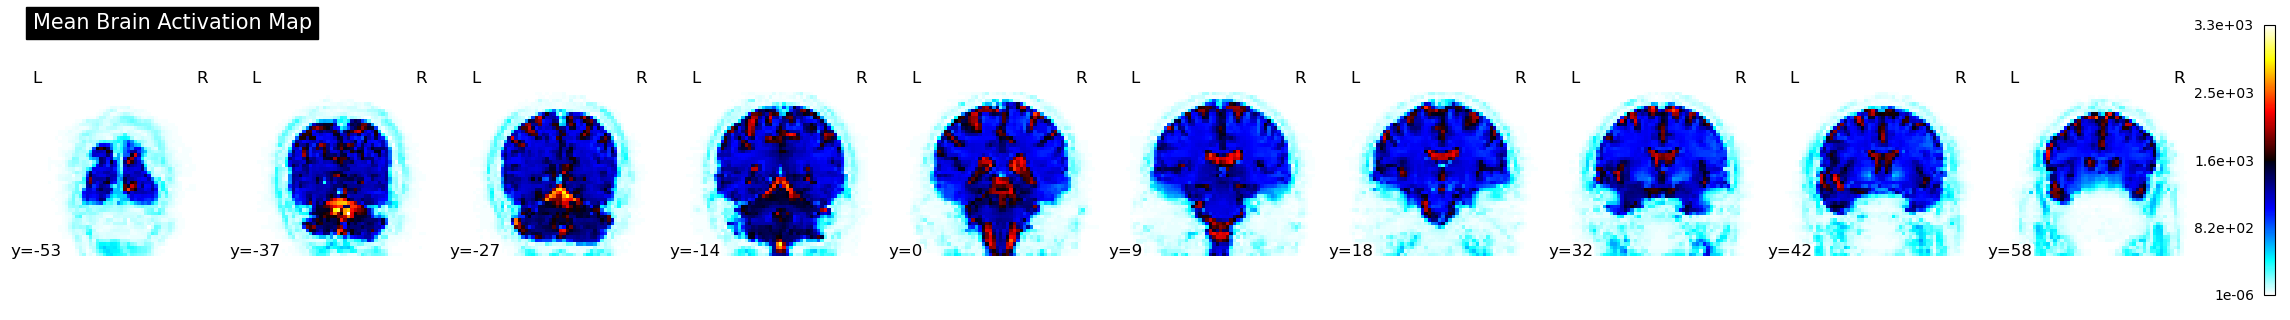

In [24]:
# Now, plot the 3D NIfTI
plotting.plot_stat_map(mean_nifti_path, display_mode='y', cut_coords=10, title="Mean Brain Activation Map")
plotting.show()

In [25]:
# z → Axial view (top-down)

# x → Sagittal view (side view)

# y → Coronal view (front-to-back)


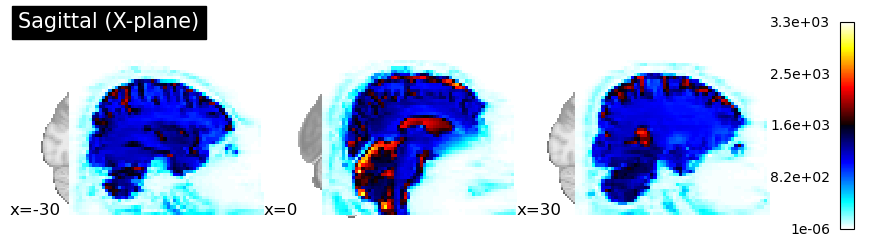

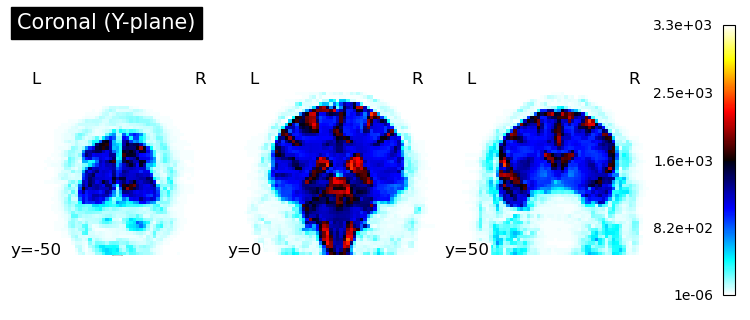

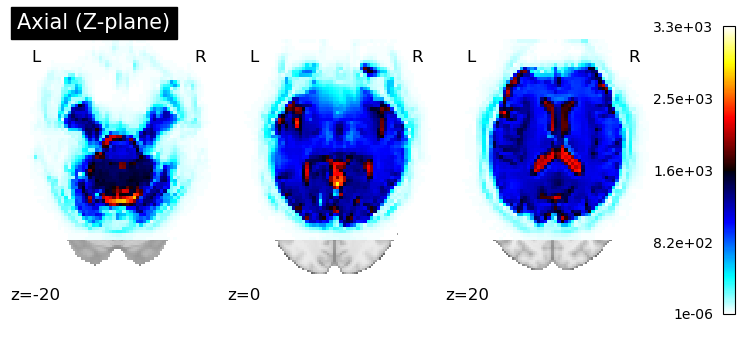

In [26]:
from nilearn import plotting

# Display slices along different axes
plotting.plot_stat_map(mean_nifti_path, display_mode='x', cut_coords=[-30, 0, 30], title="Sagittal (X-plane)")
plotting.plot_stat_map(mean_nifti_path, display_mode='y', cut_coords=[-50, 0, 50], title="Coronal (Y-plane)")
plotting.plot_stat_map(mean_nifti_path, display_mode='z', cut_coords=[-20, 0, 20], title="Axial (Z-plane)")

plotting.show()

In [27]:
def process_and_display_fmri(file_path, output_path=None, display=True, cut_coords=10, display_mode='z'):
    """
    Process a 4D fMRI NIfTI file by converting it to 3D (mean across time) and optionally display it.
    
    Parameters:
    -----------
    file_path : str
        Path to the 4D fMRI NIfTI file
    output_path : str, optional
        Path to save the resulting 3D mean NIfTI file. If None, will use "mean_fmri_3d.nii.gz"
    display : bool, optional
        Whether to display the results (default: True)
    cut_coords : int or list, optional
        Number of cuts or specific cut coordinates for display (default: 10)
    display_mode : str, optional
        Display mode for visualization: 'x', 'y', 'z', 'ortho', etc. (default: 'z')
        
    Returns:
    --------
    mean_nifti : nibabel.nifti1.Nifti1Image
        The 3D mean NIfTI image object
    mean_nifti_path : str
        Path to the saved 3D mean NIfTI file
    """
    import nibabel as nib
    import numpy as np
    from nilearn import plotting
    import os
    
    # Set default output path if not provided
    if output_path is None:
        base_dir = os.path.dirname(file_path)
        output_path = os.path.join(base_dir, "mean_fmri_3d.nii.gz")
    
    print(f"Loading 4D fMRI data from: {file_path}")
    # Load the 4D fMRI NIfTI file
    fmri_img = nib.load(file_path)
    
    # Get the data dimensions
    shape = fmri_img.shape
    print(f"Image dimensions: {shape}")
    
    # Convert 4D to 3D: Take the mean across time
    print("Computing mean across time dimension...")
    fmri_data = fmri_img.get_fdata()
    mean_fmri_3d = np.mean(fmri_data, axis=-1)  # Averaging across time
    
    # Save the 3D mean image as a new NIfTI file
    print(f"Saving 3D mean image to: {output_path}")
    mean_nifti = nib.Nifti1Image(mean_fmri_3d, affine=fmri_img.affine)
    nib.save(mean_nifti, output_path)
    
    # Plot the 3D NIfTI if requested
    if display:
        print("Displaying mean brain activation map...")
        plot = plotting.plot_stat_map(
            output_path, 
            display_mode=display_mode, 
            cut_coords=cut_coords, 
            title="Mean Brain Activation Map"
        )
        plotting.show()
    
    return mean_nifti, output_path

# Example usage:
# mean_img, saved_path = process_and_display_fmri("path/to/your/fmri.nii.gz")

In [33]:
import pandas as pd
df = pd.read_csv(r'C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\fMRI_4_12_2025.csv')

In [61]:
df[df['Image Data ID']=='I358614']

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
399,I358614,002_S_5018,AD,M,74,v04,fMRI,Resting State fMRI,Original,2/11/2013,DCM,3/25/2025


In [52]:
def get_image_ids(df, group):
    return df[df['Group'] == group]['Image Data ID'].to_list()

In [54]:
cn_image_ids = get_image_ids(df, 'CN')
ad_image_ids = get_image_ids(df, 'AD')
mci_image_ids = get_image_ids(df, 'MCI')


In [43]:
import os

def check_folder_exists(main_directory, folder_name):
    """
    Check if a folder exists within a specified directory
    
    Parameters:
    -----------
    main_directory : str
        Path to the main directory
    folder_name : str
        Name of the folder to check for
        
    Returns:
    --------
    bool
        True if the folder exists, False otherwise
    """
    folder_path = os.path.join(main_directory, folder_name)
    exists = os.path.isdir(folder_path)
    

    return exists

# Example usage:
main_dir = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output"


In [79]:
for id in ad_image_ids:
    folder_to_check =id  # Replace with the folder name you want to check

    exists = check_folder_exists(main_dir, folder_to_check)
    if exists:
        print(f"The folder '{folder_to_check}' exists in the directory.")
        break
for id in cn_image_ids:
    folder_to_check =id  # Replace with the folder name you want to check

    exists = check_folder_exists(main_dir, folder_to_check)
    if exists:
        print(f"The folder '{folder_to_check}' exists in the directory.")
        break   
for id in mci_image_ids:
    folder_to_check =id  # Replace with the folder name you want to check

    exists = check_folder_exists(main_dir, folder_to_check)
    if exists:
        print(f"The folder '{folder_to_check}' exists in the directory.")
        break   

The folder 'I358614' exists in the directory.
The folder 'I1590193' exists in the directory.
The folder 'I1429980' exists in the directory.


In [58]:
import os

def list_files_in_directory(directory):
    """
    Lists all files (not folders) inside a specified directory
    
    Parameters:
    -----------
    directory : str
        Path to the directory to check
        
    Returns:
    --------
    list
        A list of filenames (not folders) in the directory
    """
    if not os.path.exists(directory):
        print(f"The directory {directory} does not exist.")
        return []
    
    # Get only files, not directories
    files = [item for item in os.listdir(directory) 
            if os.path.isfile(os.path.join(directory, item))]
    
    print(f"Found {len(files)} files in {directory}:")
    for file in files:
        print(f"- {file}")
    
    return files

# Example usage
directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614"
files_list = list_files_in_directory(directory_path)

Found 1 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614:
- 501_resting_state_fmri.nii.gz


In [65]:
import os

def list_files_in_directory(directory):
    """
    Lists all files (not folders) inside a specified directory
    
    Parameters:
    -----------
    directory : str
        Path to the directory to check
        
    Returns:
    --------
    list
        A list of filenames (not folders) in the directory
    """
    if not os.path.exists(directory):
        print(f"The directory {directory} does not exist.")
        return []
    
    # Get only files, not directories
    files = [item for item in os.listdir(directory) 
            if os.path.isfile(os.path.join(directory, item))]
    
    print(f"Found {len(files)} files in {directory}:")
    for file in files:
        print(f"- {file}")
    
    return files

# Example usage
directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614"
files_list = list_files_in_directory(directory_path)
file_dir = f'{directory_path}\\{files_list[0]}'

directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193"
files_list = list_files_in_directory(directory_path)
file_dir = f'{directory_path}\\{files_list[0]}'
print(f'{file_dir} for I1590193')

Found 2 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614:
- 501_resting_state_fmri.nii.gz
- mean_fmri_3d.nii.gz
Found 1 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193:
- 9_axial_rsfmri_eyes_open.nii.gz
C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193\9_axial_rsfmri_eyes_open.nii.gz for I1590193


For CN Patient
Loading 4D fMRI data from: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I552093\501_extended_resting_state_fmri.nii.gz
Image dimensions: (64, 64, 48, 200)
Computing mean across time dimension...
Saving 3D mean image to: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I552093\mean_fmri_3d.nii.gz
Displaying mean brain activation map...


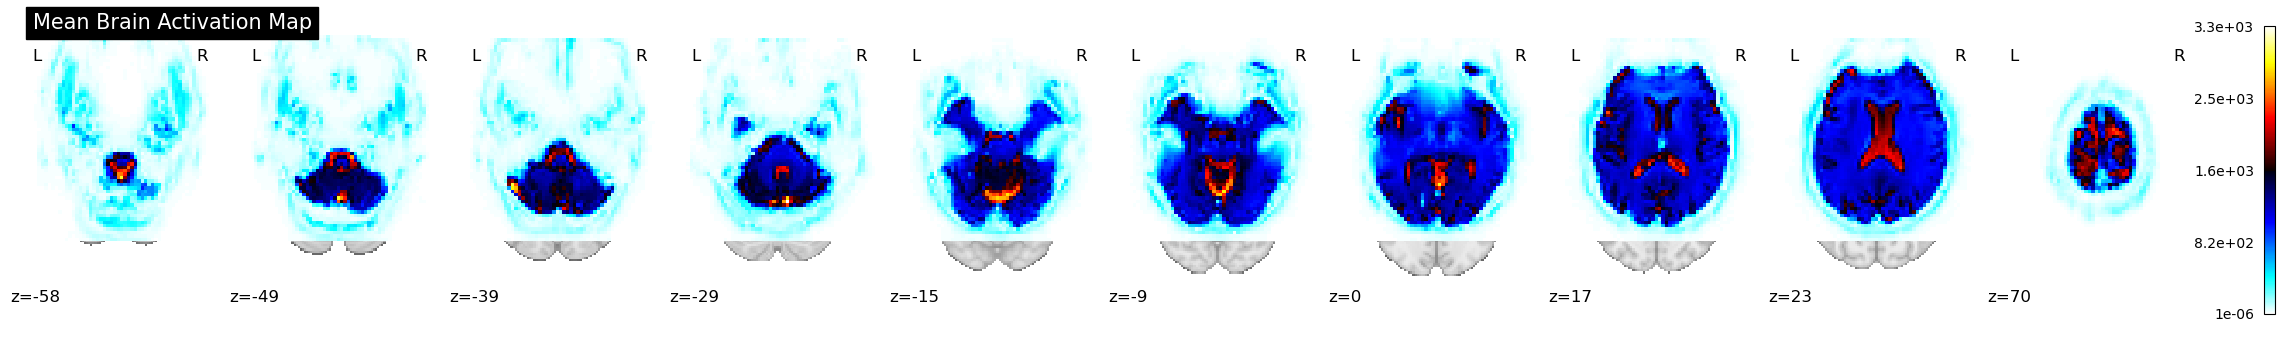

(<nibabel.nifti1.Nifti1Image at 0x267403b7230>,
 'C:\\Users\\as3211\\Downloads\\Alzheimer_detection-main\\Alzheimer_detection-main\\ADNI\\output\\I552093\\mean_fmri_3d.nii.gz')

In [51]:
print("For CN Patient")
process_and_display_fmri(file_dir)

In [81]:
import os
import nibabel as nib
import numpy as np
from nilearn import plotting

def list_files_in_directory(directory):
    """
    Lists all files (not folders) inside a specified directory
    
    Parameters:
    -----------
    directory : str
        Path to the directory to check
        
    Returns:
    --------
    list
        A list of filenames (not folders) in the directory
    """
    if not os.path.exists(directory):
        print(f"The directory {directory} does not exist.")
        return []
    
    # Get only files, not directories
    files = [item for item in os.listdir(directory) 
            if os.path.isfile(os.path.join(directory, item))]
    
    print(f"Found {len(files)} files in {directory}:")
    for file in files:
        print(f"- {file}")
    
    return files

def process_and_display_fmri(file_path, output_path=None, display=True, cut_coords=10, display_mode='z'):
    """
    Process a 4D fMRI NIfTI file by converting it to 3D (mean across time) and optionally display it.
    
    Parameters:
    -----------
    file_path : str
        Path to the 4D fMRI NIfTI file
    output_path : str, optional
        Path to save the resulting 3D mean NIfTI file. If None, will use "mean_fmri_3d.nii.gz"
    display : bool, optional
        Whether to display the results (default: True)
    cut_coords : int or list, optional
        Number of cuts or specific cut coordinates for display (default: 10)
    display_mode : str, optional
        Display mode for visualization: 'x', 'y', 'z', 'ortho', etc. (default: 'z')
        
    Returns:
    --------
    mean_nifti : nibabel.nifti1.Nifti1Image
        The 3D mean NIfTI image object
    mean_nifti_path : str
        Path to the saved 3D mean NIfTI file
    """
    # Set default output path if not provided
    if output_path is None:
        base_dir = os.path.dirname(file_path)
        output_path = os.path.join(base_dir, "mean_fmri_3d.nii.gz")
    
    print(f"Loading 4D fMRI data from: {file_path}")
    # Load the 4D fMRI NIfTI file
    fmri_img = nib.load(file_path)
    
    # Get the data dimensions
    shape = fmri_img.shape
    print(f"Image dimensions: {shape}")
    
    # Convert 4D to 3D: Take the mean across time
    print("Computing mean across time dimension...")
    fmri_data = fmri_img.get_fdata()
    mean_fmri_3d = np.mean(fmri_data, axis=-1)  # Averaging across time
    
    # Save the 3D mean image as a new NIfTI file
    print(f"Saving 3D mean image to: {output_path}")
    mean_nifti = nib.Nifti1Image(mean_fmri_3d, affine=fmri_img.affine)
    nib.save(mean_nifti, output_path)
    plotting.plot_stat_map(mean_nifti_path, display_mode='x', cut_coords=[-30, 0, 30], title="Sagittal (X-plane)")
    plotting.plot_stat_map(mean_nifti_path, display_mode='y', cut_coords=[-50, 0, 50], title="Coronal (Y-plane)")
    plotting.plot_stat_map(mean_nifti_path, display_mode='z', cut_coords=[-20, 0, 20], title="Axial (Z-plane)")
    # Plot the 3D NIfTI if requested
    if display:
        print("Displaying mean brain activation map...")
        plot = plotting.plot_stat_map(
            output_path, 
            display_mode=display_mode, 
            cut_coords=cut_coords, 
            title="Mean Brain Activation Map"
        )
        plotting.show()
    
    return mean_nifti, output_path

def process_directory_fmri(directory_path):
    """
    Lists files in a directory and processes the first fMRI file found
    
    Parameters:
    -----------
    directory_path : str
        Path to the directory containing fMRI files
        
    Returns:
    --------
    result : tuple or None
        If successful, returns the tuple from process_and_display_fmri
        If unsuccessful, returns None
    """
    # Get list of files in the directory
    files_list = list_files_in_directory(directory_path)
    
    if not files_list:
        print("No files found to process.")
        return None
    
    # Create full path to the first file
    file_dir = os.path.join(directory_path, files_list[0])
    print(f"Processing first file: {file_dir}")
    
    # Process the file
    try:
        result = process_and_display_fmri(file_dir)
        return result
    except Exception as e:
        print(f"Error processing file {file_dir}: {str(e)}")
        return None



For AD Patient image data I358614
Found 2 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614:
- 501_resting_state_fmri.nii.gz
- mean_fmri_3d.nii.gz
Processing first file: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614\501_resting_state_fmri.nii.gz
Loading 4D fMRI data from: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614\501_resting_state_fmri.nii.gz
Image dimensions: (64, 64, 48, 140)
Computing mean across time dimension...
Saving 3D mean image to: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614\mean_fmri_3d.nii.gz
Displaying mean brain activation map...


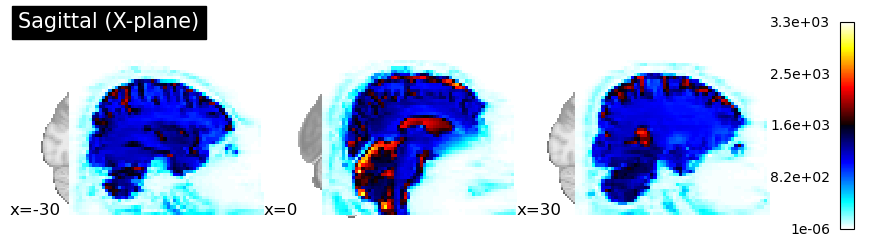

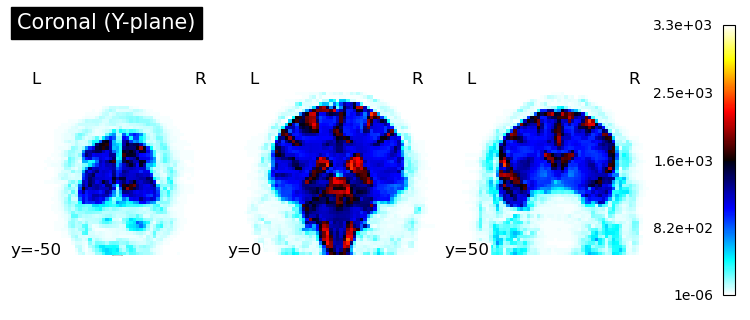

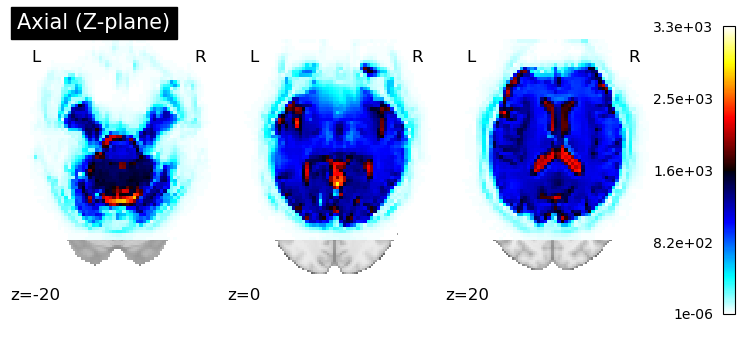

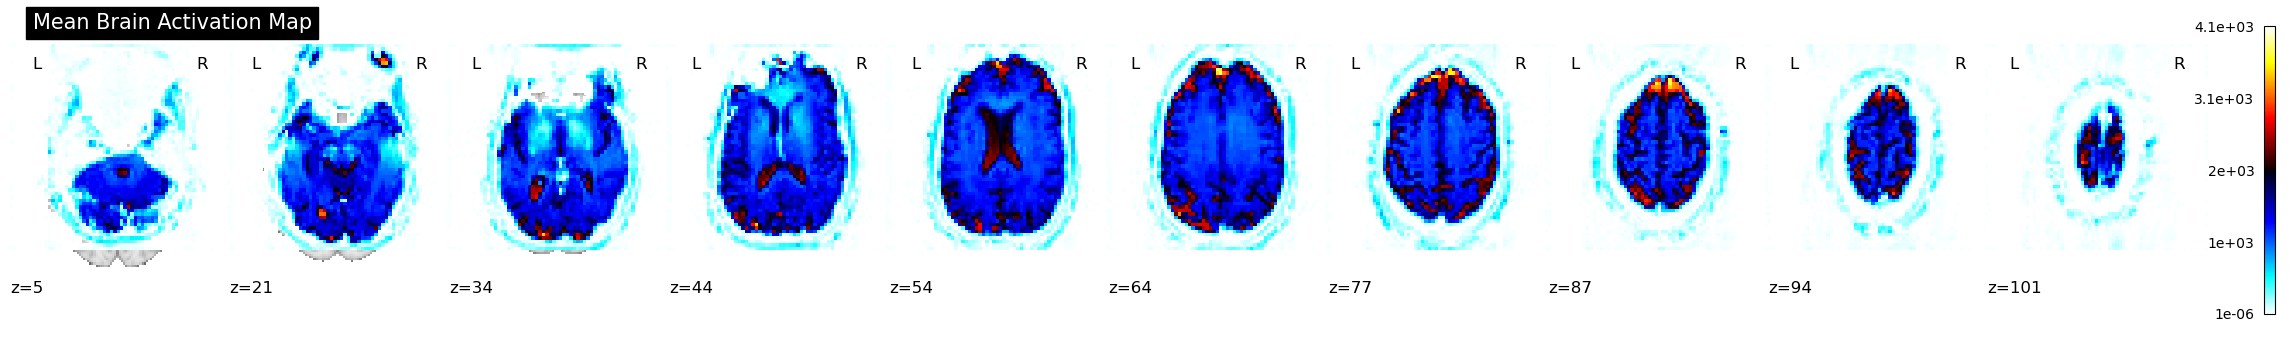

(<nibabel.nifti1.Nifti1Image at 0x2674a04c950>,
 'C:\\Users\\as3211\\Downloads\\Alzheimer_detection-main\\Alzheimer_detection-main\\ADNI\\output\\I358614\\mean_fmri_3d.nii.gz')

In [82]:

print(f'For AD Patient image data I358614')
directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I358614"
process_directory_fmri(directory_path)




For CD Patient image data I1590193
Found 2 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193:
- 9_axial_rsfmri_eyes_open.nii.gz
- mean_fmri_3d.nii.gz
Processing first file: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193\9_axial_rsfmri_eyes_open.nii.gz
Loading 4D fMRI data from: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193\9_axial_rsfmri_eyes_open.nii.gz
Image dimensions: (64, 64, 48, 197)
Computing mean across time dimension...
Saving 3D mean image to: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193\mean_fmri_3d.nii.gz
Displaying mean brain activation map...


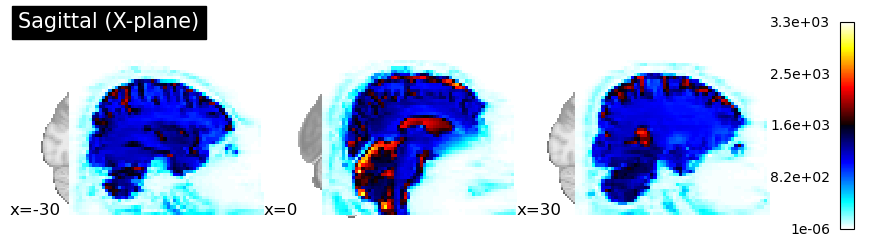

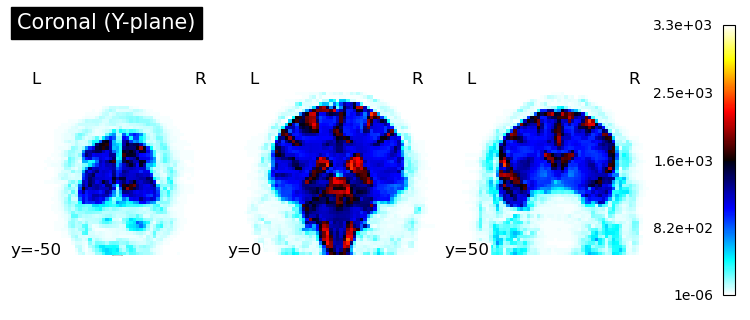

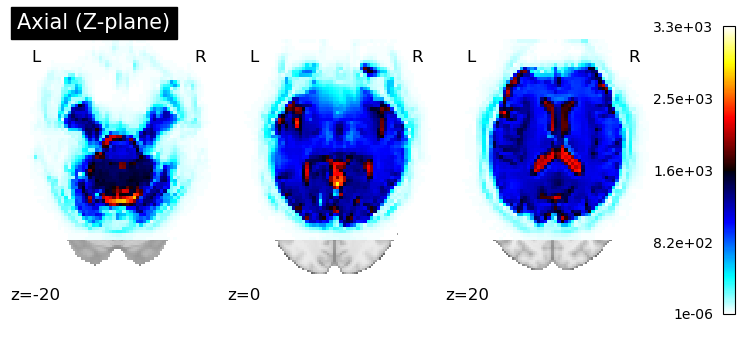

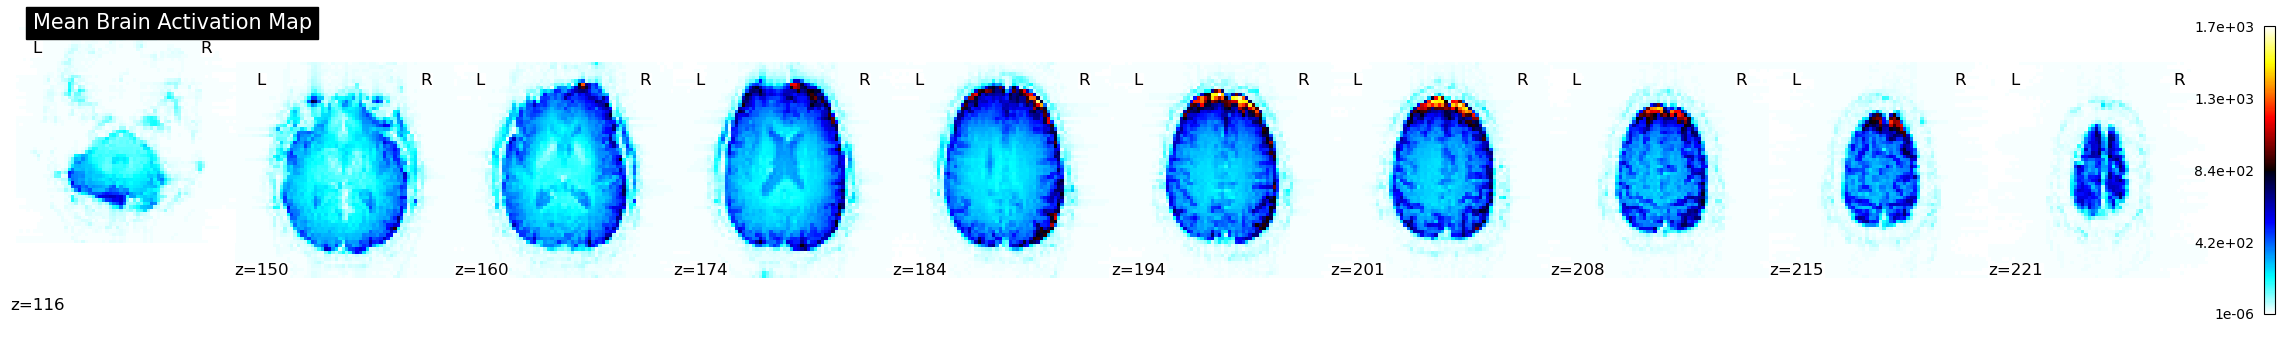

(<nibabel.nifti1.Nifti1Image at 0x267196a1e80>,
 'C:\\Users\\as3211\\Downloads\\Alzheimer_detection-main\\Alzheimer_detection-main\\ADNI\\output\\I1590193\\mean_fmri_3d.nii.gz')

In [83]:
print(f'For CD Patient image data I1590193')
directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1590193"
process_directory_fmri(directory_path)



For MCI Patient image data I1429980
Found 2 files in C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1429980:
- 11_axial_rsfmri_eyes_open.nii.gz
- mean_fmri_3d.nii.gz
Processing first file: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1429980\11_axial_rsfmri_eyes_open.nii.gz
Loading 4D fMRI data from: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1429980\11_axial_rsfmri_eyes_open.nii.gz
Image dimensions: (64, 64, 48, 197)
Computing mean across time dimension...
Saving 3D mean image to: C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1429980\mean_fmri_3d.nii.gz
Displaying mean brain activation map...


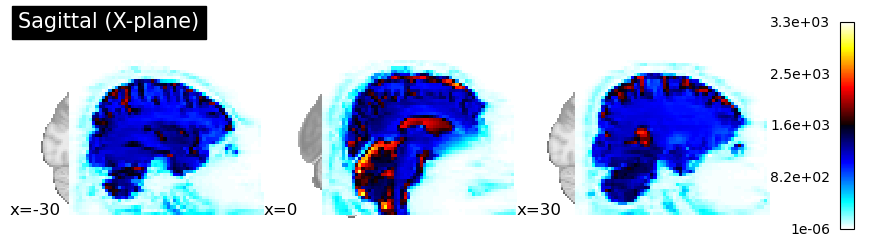

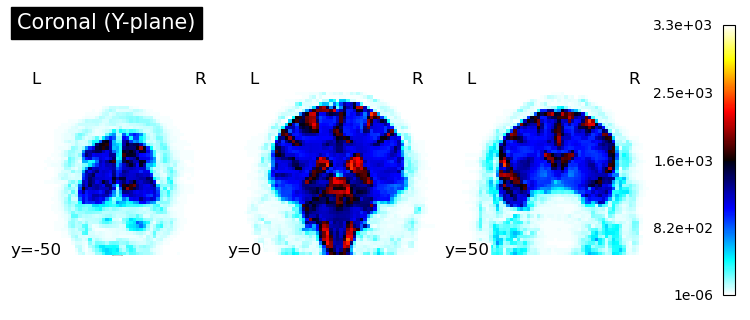

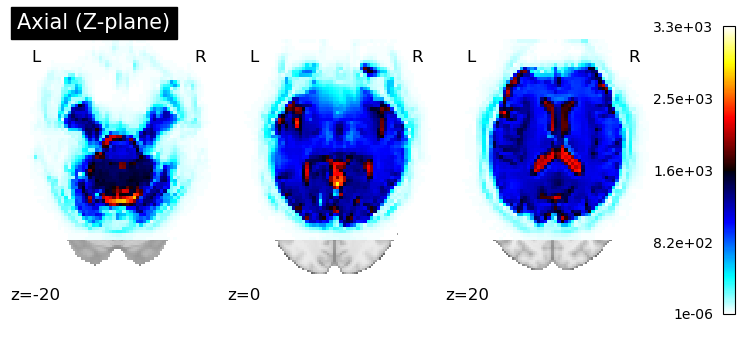

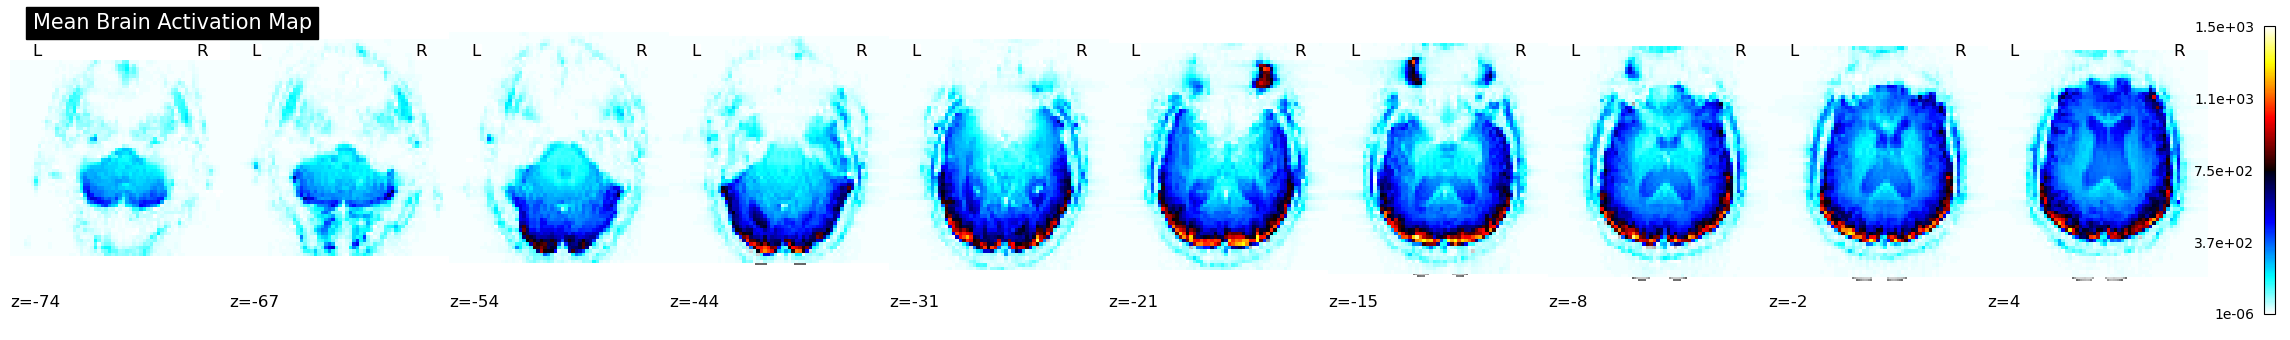

(<nibabel.nifti1.Nifti1Image at 0x26749ec40b0>,
 'C:\\Users\\as3211\\Downloads\\Alzheimer_detection-main\\Alzheimer_detection-main\\ADNI\\output\\I1429980\\mean_fmri_3d.nii.gz')

In [84]:
print(f'For MCI Patient image data I1429980')
directory_path = r"C:\Users\as3211\Downloads\Alzheimer_detection-main\Alzheimer_detection-main\ADNI\output\I1429980"
process_directory_fmri(directory_path)
